# An EGFR Review Assistant for Lung Slides: Look, Zoom, Compare, Explain

**The idea:** a pathologist doesn't read every inch of a slide at high magnification. They scan it at low power, find the suspicious areas, zoom into those, and stop once they are confident. They also compare with cases they have seen before. This notebook builds a simple **agent** that works the same way, on top of the EGFR model from my lung notebook, and presents its work as a **review tool for a pathologist**:

1. **Look:** score every region of the slide at low magnification (5x).
2. **Zoom:** visit the most important regions one by one at high magnification (20x), update the EGFR prediction after each zoom, and **stop when confident** or when a budget runs out.
3. **Compare:** find the most similar past cases, using only the regions the agent looked at.
4. **Explain:** a safety rule in code decides the recommendation, and an LLM writes a short summary.

**The tool never decides.** It shows the pathologist where it looked, what drove its answer, close-ups of those areas, and similar past cases with their known EGFR status, so they can judge for themselves.

**Why I built this:** reading every tile of a gigapixel slide is slow. I wanted a tool that looks at a slide more like a person does, and then shows its evidence instead of handing over a single number.

## How I built this notebook

**My part:** the idea of an agent that chooses which regions to zoom into instead of reading the whole scan, retrieving similar past cases as evidence, and presenting it all as a review tool for a pathologist. I chose the stopping rule, the comparisons, and the rule that the LLM never makes the safety decision. I ran every cell and wrote the interpretation sections.

**AI-assisted part:** the code was written with Claude (Anthropic's AI assistant), based on the design I described and my guidance through each part. The case summaries in Part 6 are written by Claude Haiku 4.5 through the Claude API. I went through each function so I can explain what it does and why.

---
## Setup

**Inputs to add with Add Input:**
1. The **output of my lung EGFR notebook** (cached embeddings, fold models, fold assignments, thumbnails).
2. My **TCGA-LUAD mutation dataset**, used only to show the exact EGFR mutation of past cases (for example "exon 19 deletion").

**For the LLM summaries (Part 6):** add a Claude API key as a Kaggle Secret named `ANTHROPIC_API_KEY` (Add-ons → Secrets). A free Gemini key also works: name it `GEMINI_API_KEY` and set `LLM_PROVIDER = 'gemini'`. Without a key, the notebook still runs and uses a simple template summary.

**Internet** must be on: the close-up views re-download a few slides from the GDC.

In [39]:
!pip install -q openslide-python openslide-bin google-genai

In [40]:
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeout
import os, json, re, time, random, textwrap

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import openslide
from PIL import Image

import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Colors: blue = wild-type / whole slide, orange = mutant / agent, red = "look here"
C_WT, C_MUT, C_GRAY, C_RED = '#2a78d6', '#eb6834', '#8a8a8a', '#d62728'

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Using device: cuda


In [41]:
# ---------------- Config ----------------
def find_file(name, root='/kaggle/input'):
    # Searches all attached inputs for a file name (follows Kaggle's linked folders)
    for folder, _, files in os.walk(root, followlinks=True):
        if name in files:
            return os.path.join(folder, name)
    return None

# My lung notebook's output folder (set it by hand here if the search doesn't find it)
LUNG_DIR = None
if LUNG_DIR is None:
    _f = find_file('oof_predictions.csv')
    assert _f, 'Add the output of my lung EGFR notebook with Add Input (or set LUNG_DIR by hand)'
    LUNG_DIR = os.path.dirname(_f)
CACHE_DIR = sorted(os.path.join(LUNG_DIR, d) for d in os.listdir(LUNG_DIR) if d.startswith('cache'))[0]
THUMB_DIR = f'{LUNG_DIR}/thumbs'
MODEL_DIR = f'{LUNG_DIR}/models'
print('Lung notebook output:', LUNG_DIR)

# My mutation dataset (optional: only used to name the exact mutation of past cases)
MUTATION_PATH = '/kaggle/input/datasets/soaadhamood34/tcga-luad-mutation-data/data_mutations.txt'

WORK = '/kaggle/working'
SLIDE_TMP = f'{WORK}/slides_tmp'
os.makedirs(SLIDE_TMP, exist_ok=True)
SEED = 0

# The agent
CONFIDENT = 0.75      # stop when the prediction is >= 0.75 or <= 0.25
MIN_ZOOMS = 4         # always look at at least 4 regions before stopping
MAX_ZOOMS = 16        # budget: never more than 16 regions

# Evaluation
BUDGETS = [2, 4, 8, 16, 32, 64]   # fixed numbers of regions for the budget curve
N_RANDOM_REPEATS = 3

# The 5x "look" model
EPOCHS_LOW = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
TILES_PER_STEP = 512

# Retrieval and the case review
TOP_K = 5             # similar past cases per slide
N_COMPARE = 3         # how many of them to compare up close in the case review
N_DECISION_REGIONS = 3  # red boxes: regions that mattered most for the decision
SHOW_CLOSEUPS = True  # re-downloads the reviewed slides (and their closest past cases) to show close-ups

# LLM summaries
LLM_PROVIDER = 'claude'                  # 'claude', 'gemini' or 'template'
GEMINI_MODEL = 'gemini-3.8-flash'        # check Google's quickstart if this name changes
CLAUDE_MODEL = 'claude-haiku-4-5-20251001'
MAX_LLM_CALLS = 30                       # hard limit on API calls per run (Gemini's free tier allows about 20 a day)
LLM_TIMEOUT = 60                         # seconds to wait for one answer before giving up
LLM_PAUSE_SECONDS = 1                    # wait between calls (use 5 for Gemini's free tier)

Lung notebook output: /kaggle/input/notebooks/soaadhamood34/lung-egfr-v1


---
# Part 1: Loading My Lung Notebook's Results

I load the cached embeddings, the fold each slide was held out in, and the 20x gated attention models (one per fold). Then I **check that everything loaded correctly**: running each fold's model on its held-out slides should reproduce the predictions my lung notebook saved.

In [42]:
run_info = json.load(open(f'{LUNG_DIR}/run_info.json'))
EMBED_DIM, N_FOLDS, LUNG_SEED = run_info['embed_dim'], run_info['n_folds'], run_info['seeds'][0]

data = pd.read_csv(f'{LUNG_DIR}/oof_predictions.csv')
data = data[data['slide_id'].apply(lambda s: os.path.exists(f'{CACHE_DIR}/{s}.pt'))].reset_index(drop=True)
cache = {sid: torch.load(f'{CACHE_DIR}/{sid}.pt') for sid in tqdm(data.slide_id, desc='Loading cache')}

ids = data['slide_id'].values
y = data['egfr_mutant'].values.astype(int)
fold = data[f'fold_seed{LUNG_SEED}'].values
fold_of = dict(zip(ids, fold))
label_of = dict(zip(ids, y))
print(f'{len(ids)} slides, {y.sum()} EGFR-mutant, {N_FOLDS} folds, encoder: {run_info["encoder"]}')

Loading cache:   0%|          | 0/75 [00:00<?, ?it/s]

75 slides, 25 EGFR-mutant, 5 folds, encoder: phikon


In [43]:
# Same model class as my lung notebook (the saved weights only fit this exact architecture)
class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, attn_dim=128, dropout=0.25):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attn_tanh = nn.Sequential(nn.Linear(hidden_dim, attn_dim), nn.Tanh(), nn.Dropout(dropout))
        self.attn_gate = nn.Sequential(nn.Linear(hidden_dim, attn_dim), nn.Sigmoid(), nn.Dropout(dropout))
        self.attn_score = nn.Linear(attn_dim, 1)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, bag):
        h = self.proj(bag)
        scores = self.attn_score(self.attn_tanh(h) * self.attn_gate(h)).squeeze(-1)
        weights = torch.softmax(scores, dim=0)
        slide_vector = (weights.unsqueeze(-1) * h).sum(dim=0)
        return self.classifier(slide_vector).squeeze(-1), weights

hi_models = {}
for k in range(N_FOLDS):
    m = GatedAttentionMIL(EMBED_DIM).to(device)
    m.load_state_dict(torch.load(f'{MODEL_DIR}/gated_attn_seed{LUNG_SEED}_fold{k}.pt', map_location=device))
    hi_models[k] = m.eval()

def get_bag(sid, key='hi_emb', idx=None):
    bag = cache[sid][key]
    if idx is not None:
        bag = bag[torch.as_tensor(np.asarray(idx), dtype=torch.long)]
    return bag.float().to(device)

@torch.no_grad()
def predict_hi(sid, tile_idx=None):
    # EGFR probability (and tile attention) from the 20x model of the fold where this slide was held out
    logit, w = hi_models[fold_of[sid]](get_bag(sid, 'hi_emb', tile_idx))
    return torch.sigmoid(logit).item(), w.cpu().numpy()

# Check: whole-slide predictions should match what the lung notebook saved
p_whole = np.array([predict_hi(s)[0] for s in ids])
diff = np.abs(p_whole - data[f'oof_prob_seed{LUNG_SEED}'].values).max()
print(f'Largest difference from the saved predictions: {diff:.6f} (expect about 0)')
print(f'Whole-slide AUROC: {roc_auc_score(y, p_whole):.3f}')

Largest difference from the saved predictions: 0.000000 (expect about 0)
Whole-slide AUROC: 0.650


In [44]:
# The exact EGFR mutation of each mutant patient, to show next to past cases
HOTSPOTS = {'L858R', 'L861Q', 'S768I', 'T790M', 'G719A', 'G719S', 'G719C', 'G719D'}

def mutation_name(rows):
    # The driver mutation(s) of a patient, using the same rules as my lung notebook.
    # Some patients also carry extra EGFR changes that are not drivers, so I skip those.
    drivers = []
    for _, r in rows.iterrows():
        exon = str(r.get('EXON', r.get('Exon_Number', ''))).split('/')[0]
        change = str(r['HGVSp_Short']).replace('p.', '')
        if r['Variant_Classification'] == 'In_Frame_Del' and exon == '19':
            drivers.append('exon 19 deletion')
        elif r['Variant_Classification'] == 'In_Frame_Ins' and exon == '20':
            drivers.append('exon 20 insertion')
        elif change in HOTSPOTS:
            drivers.append(change)
    return ' + '.join(dict.fromkeys(drivers)) if drivers else None

mutation_of = {}
if os.path.exists(MUTATION_PATH):
    mut = pd.read_csv(MUTATION_PATH, sep='\t', comment='#', low_memory=False)
    mut['patient'] = mut['Tumor_Sample_Barcode'].astype(str).str[:12]
    egfr = mut[(mut['Hugo_Symbol'].str.upper() == 'EGFR') & (mut['Variant_Classification'] != 'Silent')]
    for p in data.loc[data.egfr_mutant == 1, 'patient']:
        rows = egfr[egfr['patient'] == p]
        if len(rows) and mutation_name(rows):
            mutation_of[p] = mutation_name(rows)
print(f'Exact mutation found for {len(mutation_of)} of {int(y.sum())} mutant patients')

def status_text(sid):
    if not label_of[sid]:
        return 'EGFR wild-type'
    p = data.loc[data.slide_id == sid, 'patient'].iloc[0]
    return f"EGFR-mutant ({mutation_of[p]})" if p in mutation_of else 'EGFR-mutant'

Exact mutation found for 25 of 25 mutant patients


---
# Part 2: The "Look" Model at 5x

To decide where to zoom, the agent needs a score for every **5x region** (the low-magnification view, about 0.5 mm of tissue each, where the layout of the tissue is visible but not the details of each cell). My lung notebook already saved one embedding per 5x region. I train a second gated attention model on these region embeddings, with exactly the same folds, so for each slide both the 5x and the 20x model come from the fold where that slide was held out.

The attention weights of this 5x model are the agent's map of "where to look first."

### What "5x" and "20x" mean, and why there are two models

The "x" is magnification, like on a microscope. At **5x** I see a large area of tissue at once, enough to tell where the tumor, normal lung or blood is, but not the details of single cells. At **20x** I see individual cells and their nuclei. One 5x region covers the same area as a 4 x 4 grid of 20x tiles.

The agent uses two models with the same gated attention design, each with its own job:

| | 5x model (the scout) | 20x model (the expert) |
|---|---|---|
| **Sees** | Phikon embeddings of the 5x regions | Phikon embeddings of the 20x tiles |
| **Trained in** | This notebook | My lung notebook (I reuse its 5 fold models) |
| **Job** | Decide where to zoom: its attention ranks the regions | Make the EGFR prediction from the zoomed-in tiles |

This mirrors how a pathologist works: scan the slide at low power to find the areas worth checking, then zoom in to decide. The agent visits the regions in the scout's order, sends each region's 20x tiles to the expert, and updates the prediction after every zoom until it is confident or runs out of budget.

In [45]:
def train_low_model(train_ids, seed):
    set_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    model = GatedAttentionMIL(EMBED_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    labels = np.array([label_of[s] for s in train_ids])
    n_pos = max(int(labels.sum()), 1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((len(labels) - n_pos) / n_pos, device=device))
    for epoch in range(EPOCHS_LOW):
        model.train()
        for i in torch.randperm(len(train_ids), generator=gen).tolist():
            bag = cache[train_ids[i]]['low_emb']
            if len(bag) > TILES_PER_STEP:
                bag = bag[torch.randperm(len(bag), generator=gen)[:TILES_PER_STEP]]
            logit, _ = model(bag.float().to(device))
            loss = criterion(logit, torch.tensor(float(labels[i]), device=device))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
    return model.eval()

low_models = {}
for k in range(N_FOLDS):
    low_models[k] = train_low_model(ids[fold != k], seed=SEED * 100 + k)
    print(f'Fold {k + 1}: trained on {int((fold != k).sum())} slides')

@torch.no_grad()
def look(sid):
    # One attention weight per 5x region, plus the 5x model's own EGFR probability
    logit, w = low_models[fold_of[sid]](get_bag(sid, 'low_emb'))
    return w.cpu().numpy(), torch.sigmoid(logit).item()

p_low = np.array([look(s)[1] for s in ids])
print(f'\n5x overview only, AUROC: {roc_auc_score(y, p_low):.3f}')
print(f'20x whole slide, AUROC:   {roc_auc_score(y, p_whole):.3f}')

Fold 1: trained on 60 slides
Fold 2: trained on 60 slides
Fold 3: trained on 60 slides
Fold 4: trained on 60 slides
Fold 5: trained on 60 slides

5x overview only, AUROC: 0.528
20x whole slide, AUROC:   0.650


---
# Part 3: The Agent

The agent is one function with a loop. For a slide it:

1. **Looks:** gets a weight for every 5x region from the look model, and ranks the regions from most to least important.
2. **Zooms:** takes the next region in the ranking and collects its 20x tiles (every 20x tile in my cache remembers which 5x region it came from).
3. **Predicts:** runs the 20x model on **all the tiles collected so far**.
4. **Decides whether to stop:** after at least 4 regions, it stops as soon as the prediction is confident (at least 0.75 or at most 0.25). Otherwise it continues, up to 16 regions.

It keeps a record of every step: which region, the prediction after it, and why it stopped.

**An honest note:** all embeddings were computed in advance, so here "zooming" means using the cached 20x tiles of a region. In a live system, the agent would read only those regions from the slide, which is where the real time saving comes from.

In [46]:
def zoom(sid, region):
    # The cached 20x tiles that lie inside this 5x region
    return np.where(cache[sid]['hi_parent'].numpy() == region)[0]

def run_agent(sid):
    region_w, p_overview = look(sid)
    ranking = np.argsort(-region_w)
    tiles, steps = [], []
    p = p_overview
    reason = f'budget reached ({MAX_ZOOMS} regions)'
    for region in ranking:
        if len(steps) == MAX_ZOOMS:
            break
        new_tiles = zoom(sid, region)
        if len(new_tiles) == 0:
            continue
        tiles.extend(new_tiles.tolist())
        p, _ = predict_hi(sid, tiles)
        steps.append({'region': int(region), 'p': p})
        if len(steps) >= MIN_ZOOMS and (p >= CONFIDENT or p <= 1 - CONFIDENT):
            reason = (f'confident (p = {p:.2f}, at or above {CONFIDENT})' if p >= CONFIDENT
                      else f'confident (p = {p:.2f}, at or below {1 - CONFIDENT:.2f})')
            break
    else:
        if len(steps) < MAX_ZOOMS:
            reason = 'no more regions to visit'
    return {'slide_id': sid, 'p': p, 'p_overview': p_overview, 'steps': steps, 'reason': reason,
            'regions': [s['region'] for s in steps], 'tiles': tiles,
            'n_tiles': len(tiles), 'total_tiles': len(cache[sid]['hi_emb']),
            'n_regions_total': len(region_w), 'region_w': region_w}

runs = {sid: run_agent(sid) for sid in tqdm(ids, desc='Agent')}

example_sid = ids[np.argmax(np.where(y == 1, p_whole, -1))]   # a mutant slide the model scores high
r = runs[example_sid]
print(f'Slide {example_sid[:23]} | {status_text(example_sid)} | 5x overview p = {r["p_overview"]:.2f}')
for i, s in enumerate(r['steps'], 1):
    print(f'  zoom {i:2d}: region {s["region"]:4d} -> p = {s["p"]:.2f}')
print(f'Stopped: {r["reason"]}. Read {r["n_tiles"]} of {r["total_tiles"]} 20x tiles '
      f'({100 * r["n_tiles"] / r["total_tiles"]:.1f}%).')

Agent:   0%|          | 0/75 [00:00<?, ?it/s]

Slide TCGA-86-8075-01Z-00-DX1 | EGFR-mutant (L858R) | 5x overview p = 0.99
  zoom  1: region  459 -> p = 1.00
  zoom  2: region  291 -> p = 1.00
  zoom  3: region  547 -> p = 1.00
  zoom  4: region  521 -> p = 1.00
Stopped: confident (p = 1.00, at or above 0.75). Read 16 of 3424 20x tiles (0.5%).


---
# Part 4: Does the Agent Help?

A tool is only worth using if it works. I compare three ways of reading each slide, all with the same held-out models:

| Strategy | What it reads |
|---|---|
| **Whole slide** | All cached 20x tiles |
| **Agent** | Only the regions it chose, until it stopped |
| **Random regions** | The same number of regions as the agent used on that slide, chosen at random |

The random comparison is the key test: does the agent pick **better** regions, or would any small sample of the slide do just as well? For each strategy I report the AUROC with its 95% confidence interval, and the share of tiles it had to read.

In [47]:
def bootstrap_auroc(y_true, y_prob, n=2000):
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) == 2:
            scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

def random_regions_prediction(sid, n_regions, rng):
    parent = cache[sid]['hi_parent'].numpy()
    regions = np.unique(parent)
    chosen = rng.choice(regions, min(max(1, n_regions), len(regions)), replace=False)
    return predict_hi(sid, np.where(np.isin(parent, chosen))[0])[0]

p_agent = np.array([runs[s]['p'] for s in ids])
share_read = np.array([runs[s]['n_tiles'] / runs[s]['total_tiles'] for s in ids])
rng = np.random.default_rng(SEED)
p_random = np.mean([[random_regions_prediction(s, len(runs[s]['regions']), rng) for s in ids]
                    for _ in range(N_RANDOM_REPEATS)], axis=0)

rows = []
for name, p, share in [('Whole slide', p_whole, 1.0), ('Agent', p_agent, share_read.mean()),
                       (f'Random regions (average of {N_RANDOM_REPEATS})', p_random, share_read.mean())]:
    lo, hi = bootstrap_auroc(y, p)
    rows.append({'Strategy': name, 'AUROC': roc_auc_score(y, p), '95% CI': f'{lo:.2f} to {hi:.2f}',
                 '% of 20x tiles read': 100 * share})
strategy_df = pd.DataFrame(rows)
print(strategy_df.round(3).to_string(index=False))
print('\nWhy the agent stopped:', pd.Series([r['reason'].split(' (')[0] for r in runs.values()]).value_counts().to_dict())

                     Strategy  AUROC       95% CI  % of 20x tiles read
                  Whole slide  0.650 0.51 to 0.78              100.000
                        Agent  0.599 0.46 to 0.74                2.359
Random regions (average of 3)  0.626 0.48 to 0.76                2.359

Why the agent stopped: {'confident': 75}


### The budget curve

The agent mixes two decisions: **which** regions to look at, and **when** to stop. To test the first one alone, every slide gets the **same fixed number of regions** (2, 4, 8, ... 64), picked either by attention or at random. If attention finds the informative areas, the orange line should sit above the gray one, especially at small budgets. The point where the orange line reaches the dashed line shows how few regions are enough.

 regions  attention  random
       2      0.613   0.665
       4      0.599   0.630
       8      0.590   0.631
      16      0.608   0.652
      32      0.613   0.656
      64      0.601   0.649


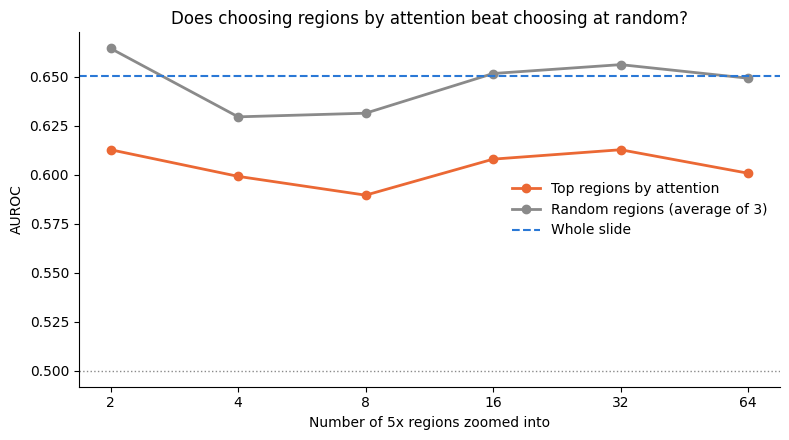

In [48]:
def top_k_prediction(sid, k):
    region_w, _ = look(sid)
    parent = cache[sid]['hi_parent'].numpy()
    ranked = [r for r in np.argsort(-region_w) if (parent == r).any()][:k]
    return predict_hi(sid, np.where(np.isin(parent, ranked))[0])[0]

curve = []
rng = np.random.default_rng(SEED + 1)
for k in BUDGETS:
    auc_top = roc_auc_score(y, [top_k_prediction(s, k) for s in ids])
    auc_rand = [roc_auc_score(y, [random_regions_prediction(s, k, rng) for s in ids]) for _ in range(N_RANDOM_REPEATS)]
    curve.append({'regions': k, 'attention': auc_top, 'random': np.mean(auc_rand)})
curve = pd.DataFrame(curve)
print(curve.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve.regions, curve.attention, marker='o', color=C_MUT, lw=2, label='Top regions by attention')
ax.plot(curve.regions, curve.random, marker='o', color=C_GRAY, lw=2, label=f'Random regions (average of {N_RANDOM_REPEATS})')
ax.axhline(roc_auc_score(y, p_whole), color=C_WT, lw=1.5, ls='--', label='Whole slide')
ax.axhline(0.5, color=C_GRAY, lw=1, ls=':')
ax.set_xscale('log', base=2); ax.set_xticks(BUDGETS); ax.set_xticklabels(BUDGETS)
ax.set_xlabel('Number of 5x regions zoomed into'); ax.set_ylabel('AUROC')
ax.set_title('Does choosing regions by attention beat choosing at random?')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What Part 4 shows:** the agent read only 2.4% of the 20x tiles and reached an AUROC of 0.60, compared with 0.65 for the whole slide, and the confidence intervals overlap a lot. But random regions did just as well (0.63), and on the budget curve random beats attention at almost every budget. So with this data, a small sample of the slide carries about as much signal as the model can use, and my 5x model (AUROC 0.53 on its own) isn't good at choosing where to look. The agent's value here is speed and a traceable record, not smarter choices.

---
# Part 5: Similar Past Cases

A prediction is easier to trust when it comes with evidence. For each slide, the agent finds the **5 most similar past cases** and checks their EGFR status, the same idea as retrieval-augmented generation (RAG) in language models, applied to slides.

**How slides are compared.** Each slide gets one **fingerprint**: the average of the embeddings of the 20x tiles in the regions the agent zoomed into. Two fingerprints are compared with **cosine similarity**: 1 means very similar, 0 means unrelated. Before comparing, I subtract the average of all fingerprints. Every slide is mostly "lung tissue," so removing what they all share leaves what makes each one different.

**Keeping it honest:** a slide can only find past cases from the *other* folds, never itself or its own held-out group.

**Does it work?** For each slide I count how many of its 5 similar cases share its EGFR status, and compare that with what picking at random would give. I also compare with fingerprints built from **all** tiles, to see whether focusing on the agent's regions helps.

In [49]:
def fingerprint(sid, idx=None):
    return get_bag(sid, 'hi_emb', idx).mean(0).cpu().numpy()

fingerprints = {
    'Agent regions': np.stack([fingerprint(s, runs[s]['tiles']) for s in ids]),
    'All tiles': np.stack([fingerprint(s) for s in ids]),
}

def retrieve(i, F, k=TOP_K):
    # The k most similar slides from the OTHER folds, by cosine similarity after centering
    gallery = np.where(fold != fold[i])[0]
    center = F[gallery].mean(0)
    G, q = F[gallery] - center, F[i] - center
    sims = (G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-8)) @ (q / (np.linalg.norm(q) + 1e-8))
    top = np.argsort(-sims)[:k]
    return gallery[top], sims[top]

rows = []
for name, F in fingerprints.items():
    same, base = [], []
    for i in range(len(ids)):
        nbrs, _ = retrieve(i, F)
        same.append(np.mean(y[nbrs] == y[i]))
        gallery_y = y[fold != fold[i]]
        base.append(np.mean(gallery_y == y[i]))
    rows.append({'Fingerprint': name, 'Similar cases with the same EGFR status': np.mean(same),
                 'Expected by random picking': np.mean(base)})
retrieval_df = pd.DataFrame(rows)
print(retrieval_df.round(3).to_string(index=False))

  Fingerprint  Similar cases with the same EGFR status  Expected by random picking
Agent regions                                    0.552                       0.556
    All tiles                                    0.592                       0.556


**What retrieval shows:** with the agent's regions, 55% of each slide's similar cases shared its EGFR status, almost exactly what random picking gives (56%). Using all tiles was a little better (59%). So the similar cases are useful for a pathologist to look at and compare, but they don't carry much EGFR signal yet. With only about 60 past cases to search, that isn't surprising.

---
# Part 6: A Safety Rule, and an LLM That Explains

The agent's record is turned into a short summary a pathologist could read. I split this into two parts on purpose:

1. **A rule in code decides the recommendation.** If the prediction is uncertain (between 0.25 and 0.75), or if the similar past cases mostly disagree with it, the recommendation is to confirm with sequencing. Otherwise it reports a consistent signal, and still says sequencing is required before any treatment decision.
2. **The LLM only writes the explanation.** It gets a "case file" with the agent's numbers and the required recommendation, and strict rules: use only numbers from the case file, copy the recommendation word for word, and say this is a research prototype, not a diagnosis.

An LLM can phrase things well, but it can also invent numbers or soften a warning, so the safety decision never depends on its wording. Then **every summary is checked automatically**.

**About privacy:** the case files contain only numbers and statuses from public TCGA data, with no patient names or images. On a free API tier, the provider may use what you send to improve its products. That's acceptable for public research data, but a real product with real patients would need a paid, privacy-safe setup.

In [50]:
DISCLAIMER = 'This is a research prototype, not a diagnosis.'

def guardrail(p, neighbor_labels):
    pred = int(p >= 0.5)
    agree = float(np.mean(np.array(neighbor_labels) == pred))
    if 1 - CONFIDENT < p < CONFIDENT:
        return 'UNCERTAIN', 'Recommend confirmatory EGFR sequencing: the image-based prediction is uncertain.'
    if agree < 0.6:
        return 'DISAGREES WITH SIMILAR CASES', 'Recommend confirmatory EGFR sequencing: the most similar past cases do not support the prediction.'
    status = 'EGFR-mutant' if pred else 'EGFR wild-type'
    return 'CONSISTENT', f'The image-based signal points to {status} and matches similar past cases, but sequencing is still required before any treatment decision.'

def build_case_file(sid):
    i = int(np.where(ids == sid)[0][0])
    r = runs[sid]
    nbrs, sims = retrieve(i, fingerprints['Agent regions'])
    status, recommendation = guardrail(r['p'], y[nbrs])
    return {
        'slide_id': sid[:23],
        'zoom_levels': '5x overview, then 20x zoom',
        'final_probability_egfr_mutant': round(r['p'], 2),
        'regions_zoomed': len(r['regions']),
        'regions_total': int(r['n_regions_total']),
        'tiles_read_20x': int(r['n_tiles']),
        'tiles_total_20x': int(r['total_tiles']),
        'percent_of_tiles_read': round(100 * r['n_tiles'] / r['total_tiles'], 1),
        'stop_reason': r['reason'],
        'confidence_threshold': CONFIDENT,
        'n_similar_cases': int(len(nbrs)),
        'similar_cases_egfr_mutant': int(y[nbrs].sum()),
        'similar_cases_egfr_wild_type': int(len(nbrs) - y[nbrs].sum()),
        'similar_cases': [{'egfr_status': status_text(ids[j]), 'similarity': round(float(s), 2)}
                          for j, s in zip(nbrs, sims)],
        'guardrail_status': status,
        'required_recommendation': recommendation,
        'required_disclaimer': DISCLAIMER,
    }

print(json.dumps(build_case_file(example_sid), indent=2))

{
  "slide_id": "TCGA-86-8075-01Z-00-DX1",
  "zoom_levels": "5x overview, then 20x zoom",
  "final_probability_egfr_mutant": 1.0,
  "regions_zoomed": 4,
  "regions_total": 856,
  "tiles_read_20x": 16,
  "tiles_total_20x": 3424,
  "percent_of_tiles_read": 0.5,
  "stop_reason": "confident (p = 1.00, at or above 0.75)",
  "confidence_threshold": 0.75,
  "n_similar_cases": 5,
  "similar_cases_egfr_mutant": 2,
  "similar_cases_egfr_wild_type": 3,
  "similar_cases": [
    {
      "egfr_status": "EGFR-mutant (exon 19 deletion)",
      "similarity": 0.73
    },
    {
      "egfr_status": "EGFR wild-type",
      "similarity": 0.29
    },
    {
      "egfr_status": "EGFR wild-type",
      "similarity": 0.27
    },
    {
      "egfr_status": "EGFR wild-type",
      "similarity": 0.27
    },
    {
      "egfr_status": "EGFR-mutant (exon 19 deletion)",
      "similarity": 0.22
    }
  ],
  "guardrail_status": "DISAGREES WITH SIMILAR CASES",
  "required_recommendation": "Recommend confirmatory EGFR 

In [51]:
SYSTEM_PROMPT = '''You write short case summaries for a pathologist reviewing a research prototype that predicts EGFR mutation status in lung adenocarcinoma from H&E whole-slide images.

Rules:
1. Use only numbers that appear in the case file, written exactly as they appear there. Do not calculate new numbers (no differences, sums, counts or percentages of your own), and do not round.
2. Copy the required_disclaimer sentence exactly, word for word, at the end of the Prediction line.
3. End with the required_recommendation sentence, copied exactly, word for word.
4. Regions and tiles are different things: regions are 5x areas, tiles are 20x squares. Do not mix them up.
5. Keep it under 120 words, in plain language, with no headings or bold text.

Format:
Prediction: <one or two sentences, then the required_disclaimer sentence>
How the slide was examined: <one or two sentences>
Similar past cases: <one sentence>
Recommendation: <the required_recommendation sentence>'''

def get_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(name)
    except Exception:
        return os.environ.get(name)

client = None
gemini_key = get_secret('GEMINI_API_KEY') or get_secret('GOOGLE_API_KEY')   # either label works
if LLM_PROVIDER == 'gemini' and gemini_key:
    from google import genai
    client = genai.Client(api_key=gemini_key)
elif LLM_PROVIDER == 'claude' and get_secret('ANTHROPIC_API_KEY'):
    !pip install -q anthropic
    import anthropic
    client = anthropic.Anthropic(api_key=get_secret('ANTHROPIC_API_KEY'))
if client is None and LLM_PROVIDER != 'template':
    print(f'No API key found for {LLM_PROVIDER}: using the template summary instead.')
    LLM_PROVIDER = 'template'
print('LLM provider:', LLM_PROVIDER)

def template_summary(case):
    # Used when no API key is available, so the notebook still runs end to end
    return (f"Prediction: The research prototype estimates a probability of {case['final_probability_egfr_mutant']} "
            f"that this slide is EGFR-mutant. {case['required_disclaimer']}\n"
            f"How the slide was examined: It zoomed into {case['regions_zoomed']} of {case['regions_total']} regions "
            f"and read {case['percent_of_tiles_read']}% of the 20x tiles, then stopped: {case['stop_reason']}.\n"
            f"Similar past cases: {case['similar_cases_egfr_mutant']} of {case['n_similar_cases']} similar cases were EGFR-mutant.\n"
            f"Recommendation: {case['required_recommendation']}")

llm_calls = 0
llm_off = False   # switched on if the API runs out of quota, so the rest of the run uses the template

def call_llm(prompt):
    if LLM_PROVIDER == 'gemini':
        return client.interactions.create(model=GEMINI_MODEL, system_instruction=SYSTEM_PROMPT, input=prompt).output_text
    reply = client.messages.create(model=CLAUDE_MODEL, max_tokens=400, system=SYSTEM_PROMPT,
                                   messages=[{'role': 'user', 'content': prompt}])
    return reply.content[0].text

def write_summary(case):
    # Returns (summary text, who wrote it). Never more than MAX_LLM_CALLS API calls per run,
    # never waits more than LLM_TIMEOUT seconds for one answer, and never crashes the notebook.
    global llm_calls, llm_off
    if LLM_PROVIDER == 'template' or llm_off or llm_calls >= MAX_LLM_CALLS:
        return template_summary(case), 'template'
    prompt = 'Case file:\n' + json.dumps(case, indent=2)
    for attempt in range(1, 4):
        llm_calls += 1
        pool = ThreadPoolExecutor(max_workers=1)
        try:
            text = pool.submit(call_llm, prompt).result(timeout=LLM_TIMEOUT)
            pool.shutdown(wait=False)
            time.sleep(LLM_PAUSE_SECONDS)
            return text, LLM_PROVIDER
        except FutureTimeout:
            pool.shutdown(wait=False)
            print(f'No answer within {LLM_TIMEOUT} s (probably the daily limit): using the template from now on')
            llm_off = True
            break
        except Exception as e:
            pool.shutdown(wait=False)
            msg = str(e)
            if '429' in msg or 'quota' in msg.lower() or 'rate limit' in msg.lower():
                print('API limit reached: using the template from now on')
                llm_off = True
                break
            if ('503' in msg or 'overloaded' in msg.lower() or 'high demand' in msg.lower()) and attempt < 3 and llm_calls < MAX_LLM_CALLS:
                print(f'The model is busy, trying again in 20 s (attempt {attempt} of 3)')
                time.sleep(20)
                continue
            print(f'LLM call failed ({msg[:120]}): using the template for this case')
            break
    return template_summary(case), 'template'

LLM provider: claude


In [ ]:
NUMBER = re.compile(r'\d+(?:\.\d+)?')

def check_summary(summary, case):
    allowed = {float(n) for n in NUMBER.findall(json.dumps(case))}
    invented = sorted({float(n) for n in NUMBER.findall(summary.replace(',', ''))} - allowed)
    return {
        'recommendation copied exactly': case['required_recommendation'] in summary,
        'no invented numbers': len(invented) == 0,
        'disclaimer copied exactly': case['required_disclaimer'] in summary,
        'under 150 words': len(summary.split()) <= 150,
        'invented': invented,
    }

# The three cases I review in Part 7 (a confident mutant, the most uncertain case, a confident wild-type).
# They are summarized first, so they always get an LLM summary even with the MAX_LLM_CALLS limit.
mut_i, wt_i = np.where(y == 1)[0], np.where(y == 0)[0]
review_ids = list(dict.fromkeys([ids[mut_i[np.argmax(p_agent[mut_i])]],
                                 ids[np.argmin(np.abs(p_agent - 0.5))],
                                 ids[wt_i[np.argmin(p_agent[wt_i])]]]))
order = review_ids + [s for s in ids if s not in review_ids]

records = {}
for sid in tqdm(order, desc='Summaries'):
    case = build_case_file(sid)
    summary, source = write_summary(case)
    records[sid] = {'case': case, 'summary': summary, 'source': source, **check_summary(summary, case)}

checks = ['recommendation copied exactly', 'disclaimer copied exactly', 'no invented numbers', 'under 150 words']
check_df = pd.DataFrame([{'slide_id': s, **r} for s, r in records.items()])
llm_df = check_df[check_df.source != 'template']
if LLM_PROVIDER == 'template':
    print('All summaries use the template (no LLM was used), so there is nothing to check.')
else:
    print(f'Summaries written by {LLM_PROVIDER}: {len(llm_df)} (the rest use the template)')
if len(llm_df):
    print((llm_df[checks].mean() * 100).round(0).astype(int).astype(str).add('% passed').to_string())
    for _, r in llm_df.iterrows():
        if not all(r[c] for c in checks):
            print(f"Failed on {r['slide_id'][:23]}: {[c for c in checks if not r[c]]} | invented numbers: {r['invented']}")

Summaries:   0%|          | 0/75 [00:00<?, ?it/s]

**What the LLM step shows:** in my first run, Claude copied the recommendation exactly in all 30 summaries, but only 57% passed the number check and 53% included the "not a diagnosis" line. Most of the flagged numbers were counts it worked out itself, like "3 were wild-type" when the case file only said 2 of 5 were mutant. It also described a confident stop as "threshold not met" and called regions "tiles", which my checks didn't catch. So I made the case file clearer (the wild-type count, tile counts and a plainer stop reason), asked for the disclaimer word for word, and ran it again: this time all 30 summaries passed all four checks. Because the recommendation is decided in code, none of these wording problems could change the safety decision.

---
# Part 7: The Case Review, What a Pathologist Would See

This is the tool as a pathologist would use it: one page per slide that shows the agent's evidence, so they can make the decision themselves.

| Panel | What it shows |
|---|---|
| **A. Where the agent looked** | A light heatmap of the 5x attention, and **numbered black boxes** in the order the agent zoomed |
| **B. What drove the decision** | **Red boxes** on the regions that mattered most for the final prediction ("look here closely") |
| **C. How confident it got** | The prediction after each zoom, and why it stopped |
| **D. Close-ups** | The 20x tiles from the red regions, for the pathologist to judge with their own eyes |
| **E. Similar past cases, up close** | For the closest past slides: a tile from this slide **next to the most similar tile from the past case**, with the past case's EGFR status and exact mutation, and a red circle on its thumbnail showing where that tile is |
| **F. Summary** | The LLM summary and the rule-based recommendation |

**How "what drove the decision" is measured:** the 20x model gives each tile an attention weight. Adding up the weights of the tiles in each visited region shows which regions contributed most to the final prediction. That can differ from where the agent looked first, and showing both is more honest.

**How the matching tiles in past cases are found:** every 20x tile has a Phikon embedding. I compare the close-up tiles from panel D with every tile of the past case (cosine similarity) and show the pair that looks most alike. That lets the pathologist put the two pieces of tissue side by side and judge for themselves whether they really look similar. To show these, the notebook downloads each compared past slide for a moment and deletes it again.

**Careful wording:** red boxes mean "highlighted for review," not "the cancer is here." Similar regions are evidence, not proof.

In [ ]:
GDC_DATA = 'https://api.gdc.cancer.gov/data'

def download_slide(file_id, file_name, expected_size, out_dir=SLIDE_TMP, attempts=5):
    path = os.path.join(out_dir, file_name)
    if os.path.exists(path) and os.path.getsize(path) == expected_size:
        return path
    session = requests.Session()
    session.mount('https://', HTTPAdapter(max_retries=Retry(total=5, backoff_factor=3,
                  status_forcelist=[429, 500, 502, 503, 504], allowed_methods=['GET'])))
    for attempt in range(1, attempts + 1):
        try:
            with session.get(f'{GDC_DATA}/{file_id}', stream=True, timeout=(30, 300)) as r:
                r.raise_for_status()
                with open(path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            if os.path.getsize(path) == expected_size:
                return path
        except Exception as e:
            print(f'Download error on {file_name} (attempt {attempt}): {e}')
            time.sleep(10 * attempt)
        if os.path.exists(path):
            os.remove(path)
    raise RuntimeError(f'Failed to download {file_name}')

def read_tile(slide, x0, y0, size0, out=256):
    level = slide.get_best_level_for_downsample(size0 / out)
    read = int(round(size0 / slide.level_downsamples[level]))
    img = slide.read_region((int(x0), int(y0)), level, (read, read)).convert('RGB')
    return np.array(img.resize((out, out), Image.BILINEAR) if read != out else img)

In [ ]:
# The average 20x tile embedding, subtracted before comparing tiles (otherwise every pair looks similar)
tile_center = torch.cat([cache[s]['hi_emb'].float() for s in ids]).mean(0)

def decision_regions(sid, n=N_DECISION_REGIONS):
    # Visited regions ranked by how much attention their tiles got in the final prediction
    r = runs[sid]
    _, w = predict_hi(sid, r['tiles'])
    parent = cache[sid]['hi_parent'].numpy()[r['tiles']]
    contrib = pd.Series(w).groupby(parent).sum().sort_values(ascending=False)
    return [int(reg) for reg in contrib.index[:n]], r['tiles'], w

def unit_tiles(sid):
    # 20x tile embeddings, centered and scaled to length 1, so a dot product is a cosine similarity
    E = cache[sid]['hi_emb'].float() - tile_center
    return (E / (E.norm(dim=1, keepdim=True) + 1e-8)).numpy()

def best_match(query_sid, query_tiles, past_sid):
    # Among the query's close-up tiles, the pair (query tile, past tile) that looks most alike
    sims = unit_tiles(past_sid) @ unit_tiles(query_sid)[query_tiles].T   # (past tiles) x (query tiles)
    p_idx, q_idx = np.unravel_index(np.argmax(sims), sims.shape)
    return int(query_tiles[q_idx]), int(p_idx), float(sims[p_idx, q_idx])

def mark_tile(ax, sid, tile, color):
    # A circle on the thumbnail around where a 20x tile sits, big enough to see
    c = cache[sid]
    sx, sy = c['thumb_scale']; size0 = c['hi_size0']
    x, yy = c['hi_coords'][tile].tolist()
    cx, cy = (x + size0 / 2) / sx, (yy + size0 / 2) / sy
    radius = 0.06 * max(ax.get_xlim()[1], abs(ax.get_ylim()[0]))
    ax.add_patch(mpatches.Circle((cx, cy), radius, fill=False, ec=color, lw=3))

def open_slide(sid):
    row = data[data.slide_id == sid].iloc[0]
    path = download_slide(row.file_id, row.file_name, row.file_size)
    return openslide.OpenSlide(path), path

def tile_image(slide, sid, tile):
    return read_tile(slide, *cache[sid]['hi_coords'][tile].tolist(), cache[sid]['hi_size0'])

def draw_boxes(ax, sid, regions, color, numbered=False, lw=2.0):
    c = cache[sid]
    sx, sy = c['thumb_scale']; s0 = c['low_size0']
    for n, reg in enumerate(regions, 1):
        x, yy = c['low_coords'][reg].tolist()
        ax.add_patch(mpatches.Rectangle((x / sx, yy / sy), s0 / sx, s0 / sy, fill=False, ec=color, lw=lw))
        if numbered:
            ax.text(x / sx + 1, yy / sy + 1, str(n), fontsize=8, fontweight='bold', va='top', ha='left',
                    bbox=dict(boxstyle='square,pad=0.1', fc='white', ec='none', alpha=0.8))

def show_heat(ax, sid, region_w):
    c = cache[sid]
    thumb = np.array(Image.open(f'{THUMB_DIR}/{sid}.png'))
    sx, sy = c['thumb_scale']; s0 = c['low_size0']
    heat = np.full(thumb.shape[:2], np.nan)
    for (x, yy), wv in zip(c['low_coords'].tolist(), region_w / region_w.max()):
        heat[int(yy / sy):int((yy + s0) / sy), int(x / sx):int((x + s0) / sx)] = wv
    ax.imshow(thumb)
    ax.imshow(heat, cmap='Oranges', alpha=0.35, vmin=0, vmax=1)
    ax.axis('off')

In [ ]:
def case_review(sid):
    i = int(np.where(ids == sid)[0][0])
    r, rec = runs[sid], records[sid]
    red, tiles, w = decision_regions(sid)
    print('=' * 100)
    print(f"CASE REVIEW | slide {sid[:23]} | agent's EGFR probability: {r['p']:.2f} | "
          f"status: {rec['case']['guardrail_status']}")
    print(f"(For evaluation only, the true label: {status_text(sid)})")

    # A + B + C: where it looked, what drove the decision, how confident it got
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [1.5, 1]})
    show_heat(axes[0], sid, r['region_w'])
    draw_boxes(axes[0], sid, r['regions'], 'black', numbered=True, lw=1.2)
    draw_boxes(axes[0], sid, red, C_RED, lw=3)
    axes[0].set_title('A + B. Where the agent looked (numbered, in order) and\n'
                      'what drove its decision (red: look here closely)')
    ps = [s['p'] for s in r['steps']]
    axes[1].plot(range(1, len(ps) + 1), ps, marker='o', color=C_MUT, lw=2)
    axes[1].axhspan(CONFIDENT, 1, color=C_MUT, alpha=0.08)
    axes[1].axhspan(0, 1 - CONFIDENT, color=C_WT, alpha=0.08)
    axes[1].axhline(0.5, color=C_GRAY, lw=1, ls='--')
    axes[1].set_xticks(range(1, len(ps) + 1)); axes[1].set_ylim(0, 1)
    axes[1].set_xlabel('Zoom number'); axes[1].set_ylabel('EGFR probability')
    axes[1].set_title(f'C. Prediction after each zoom (shaded = confident)\nStopped: {r["reason"]}')
    axes[1].spines[['top', 'right']].set_visible(False)
    plt.tight_layout(); plt.show()

    nbrs, sims = retrieve(i, fingerprints['Agent regions'])
    print('Similar past cases: ' + ' | '.join(f'{status_text(ids[j])} ({s:.2f})' for j, s in zip(nbrs, sims)))
    if not SHOW_CLOSEUPS:
        print('(Set SHOW_CLOSEUPS = True to see panels D and E)')
    else:
        # D: close-ups of the 2 highest-attention tiles in each red region
        slide, path = open_slide(sid)
        parent = cache[sid]['hi_parent'].numpy()
        picks = []
        for n, reg in enumerate(red, 1):
            in_reg = [(wk, t) for wk, t in zip(w, tiles) if parent[t] == reg]
            picks += [(n, t) for _, t in sorted(in_reg, reverse=True)[:2]]
        query_img = {t: tile_image(slide, sid, t) for _, t in picks}
        region_of = {t: n for n, t in picks}
        slide.close(); os.remove(path)
        fig, axes = plt.subplots(1, len(picks), figsize=(2.8 * len(picks), 3.2), squeeze=False)
        for ax, (n, t) in zip(axes[0], picks):
            ax.imshow(query_img[t]); ax.set_title(f'red region {n}', color=C_RED, fontsize=10); ax.axis('off')
        plt.suptitle('D. Close-ups at 20x from the red regions')
        plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

        # E: the closest past cases, compared tile to tile with this slide
        query_tiles = np.array([t for _, t in picks])
        compare = list(zip(nbrs, sims))[:N_COMPARE]
        fig, axes = plt.subplots(len(compare), 3, figsize=(13, 4.2 * len(compare)), squeeze=False,
                                 gridspec_kw={'width_ratios': [1, 1, 1.6]})
        for row_axes, (j, s) in zip(axes, compare):
            past = ids[j]
            q_tile, p_tile, tile_sim = best_match(sid, query_tiles, past)
            past_slide, past_path = open_slide(past)
            past_img = tile_image(past_slide, past, p_tile)
            past_slide.close(); os.remove(past_path)
            color = C_MUT if y[j] else C_WT
            row_axes[0].imshow(query_img[q_tile])
            row_axes[0].set_title(f'This slide (red region {region_of[q_tile]})', color=C_RED, fontsize=11)
            row_axes[1].imshow(past_img)
            row_axes[1].set_title(f'Most similar tile in the past case\ntile similarity {tile_sim:.2f}', fontsize=11)
            row_axes[2].imshow(Image.open(f'{THUMB_DIR}/{past}.png'))
            mark_tile(row_axes[2], past, p_tile, C_RED)
            row_axes[2].set_title(f'Past case: {status_text(past)}\nslide similarity {s:.2f} (red circle: where that tile is)',
                                  color=color, fontsize=11)
            for ax in row_axes:
                ax.axis('off')
        plt.suptitle(f'E. The {len(compare)} most similar past cases, compared up close', fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

    # F: summary and recommendation
    print(f"F. Summary (written by: {rec['source']})")
    for line in rec['summary'].splitlines():
        print(textwrap.fill(line, 100))
    print()

# The three example cases chosen in Part 6
for sid in review_ids:
    case_review(sid)

**What the case reviews show:** for the confident mutant case, the red regions are tumor glands, 3 of its 5 similar past cases are EGFR-mutant (all exon 19 deletions), and the side-by-side tiles in panel E show tumor next to tumor. For the confident wild-type case, the close-ups show mostly normal lung tissue (thin air-sac walls), and its best match in a past case is also normal lung. So the model based that decision on healthy tissue, not on the tumor. That's something I would only have noticed by looking, and it's exactly what this review page is for.

---
# Part 8: The Worklist, Which Cases Need a Human Most

A tool like this saves time by **sorting** the work. The worklist lists every slide with the agent's result and puts the cases that most need a pathologist at the top: first those the safety rule flagged, and among them the ones closest to 0.5.

To check that the sorting makes sense, I look at how often the image-based prediction was right in each group. If the rule works, **flagged cases should be wrong more often than consistent ones**, which is exactly why they're sent for sequencing.

In [ ]:
priority = {'UNCERTAIN': 0, 'DISAGREES WITH SIMILAR CASES': 1, 'CONSISTENT': 2}
worklist = pd.DataFrame([{
    'slide': sid[:23],
    'agent probability': round(runs[sid]['p'], 2),
    'status': records[sid]['case']['guardrail_status'],
    'regions zoomed': len(runs[sid]['regions']),
    '% tiles read': round(100 * runs[sid]['n_tiles'] / runs[sid]['total_tiles'], 1),
    'similar cases mutant': f"{records[sid]['case']['similar_cases_egfr_mutant']} of {TOP_K}",
    'true label (evaluation only)': status_text(sid),
    '_order': (priority[records[sid]['case']['guardrail_status']], abs(runs[sid]['p'] - 0.5)),
    '_correct': int(runs[sid]['p'] >= 0.5) == label_of[sid],
} for sid in ids]).sort_values('_order').reset_index(drop=True)

display(worklist.drop(columns=['_order', '_correct']).head(15))

summary_by_status = (worklist.groupby('status')
                     .agg(cases=('slide', 'count'), prediction_correct=('_correct', 'mean'))
                     .reindex(list(priority)).dropna())
summary_by_status['prediction_correct'] = (100 * summary_by_status['prediction_correct']).round(0).astype(int).astype(str) + '%'
print(summary_by_status.to_string())

**What the worklist shows:** the safety rule flagged 23 of 75 slides because their similar cases disagreed with the prediction. Among the flagged cases, the image-based prediction was right only 43% of the time, compared with 65% for the cases it called consistent. So the rule does send the harder cases to a human, and a pathologist could start from the top of this list.

In [ ]:
# Save the results
worklist.drop(columns=['_order', '_correct']).to_csv(f'{WORK}/worklist.csv', index=False)
strategy_df.to_csv(f'{WORK}/strategy_comparison.csv', index=False)
curve.to_csv(f'{WORK}/budget_curve.csv', index=False)
retrieval_df.to_csv(f'{WORK}/retrieval_results.csv', index=False)
check_df.drop(columns=['case']).to_csv(f'{WORK}/summaries.csv', index=False)
print('Saved: worklist.csv, strategy_comparison.csv, budget_curve.csv, retrieval_results.csv, summaries.csv')

---
## Summary

I built a review assistant that reads a lung slide in steps: it scans at 5x, zooms into the most important regions at 20x, and stops when confident. It read only 2.4% of the tiles and reached an AUROC of 0.60, compared with 0.65 for the whole slide, but random regions did just as well, so the agent saves time rather than choosing better. For each case it shows where it looked, what drove its answer, close-ups, and similar past cases with their EGFR status, and a safety rule in code sends doubtful cases for sequencing. The flagged cases really were the harder ones, and the decision always stays with the pathologist.

## Honest Limitations

- **Small dataset.** About 75 slides, so AUROC differences of a few hundredths are within noise. The share of tiles read is the most reliable result.
- **The zoom is simulated.** All embeddings were computed in advance, and each 5x region has up to 4 cached 20x tiles. A live tool would read only the chosen regions from the slide.
- **Hand-set thresholds.** The 0.75 confidence threshold, the budgets and the 60% agreement rule were chosen by reasoning, not tuned. The probabilities are not calibrated, so 0.75 is not a true 75% chance.
- **Small retrieval gallery.** Each slide searches about 60 past cases. Retrieval becomes truly useful with thousands.
- **Highlighted is not proven.** Red boxes show where the model put weight and which regions look alike in its features, not the biological cause of an EGFR mutation.
- **Simple LLM checks.** They catch invented numbers and missing warnings, but not every wording problem.
- **Research prototype.** Nothing here is validated for clinical use.

**One limitation I noticed myself:** the probabilities are overconfident. Almost every slide was close to 0 or 1 after only a few zooms, so all 75 stopped as "confident" at the minimum of 4 zooms, and the stopping rule never really made a decision. Calibrating the probabilities is the first thing I'd fix.

**What I learned:** an agent doesn't have to be complicated to be useful, and comparing it with a simple random baseline kept me honest about what it really adds. Looking at the case reviews taught me more about the model than the AUROC did.